In [9]:
import pandas as pd 
import seaborn as sns 
import matplotlib.pyplot as plt
import os 


from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score , classification_report , confusion_matrix
import joblib

In [10]:
df = pd.read_csv(r"C:\Users\m.rooney\Downloads\customer_churn_data.csv")

In [51]:
print (os.path.exists (r"C:\Users\m.rooney\Downloads.csv"))

False


In [52]:
df.head()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,1,0,0,1,23,0,1,2,1,1,1,1,1,1,0,1,0,49.85,1146.55,0
1,0,0,1,0,43,0,1,0,2,0,2,0,2,0,0,0,3,100.70,4330.10,1
2,1,1,0,0,51,1,0,0,0,2,2,2,0,0,1,0,2,97.33,4963.83,1
3,1,1,0,0,72,1,2,0,2,0,2,0,0,0,0,0,1,101.38,7299.36,0
4,1,1,0,0,25,1,2,0,0,0,0,2,0,2,0,0,2,52.22,1305.50,1


In [53]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5880 entries, 0 to 5879
Data columns (total 20 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   gender            5880 non-null   int64  
 1   SeniorCitizen     5880 non-null   int64  
 2   Partner           5880 non-null   int64  
 3   Dependents        5880 non-null   int64  
 4   tenure            5880 non-null   int64  
 5   PhoneService      5880 non-null   int64  
 6   MultipleLines     5880 non-null   int64  
 7   InternetService   5880 non-null   int64  
 8   OnlineSecurity    5880 non-null   int64  
 9   OnlineBackup      5880 non-null   int64  
 10  DeviceProtection  5880 non-null   int64  
 11  TechSupport       5880 non-null   int64  
 12  StreamingTV       5880 non-null   int64  
 13  StreamingMovies   5880 non-null   int64  
 14  Contract          5880 non-null   int64  
 15  PaperlessBilling  5880 non-null   int64  
 16  PaymentMethod     5880 non-null   int64  


In [54]:
df.describe()

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
count,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000,5880.000000
mean,0.501701,0.500680,0.509354,0.489116,36.549150,0.500170,1.014116,1.015816,0.992687,0.979422,1.000170,0.997789,1.005612,1.001871,0.980612,0.491497,1.507653,70.157779,2566.813165,0.492857
std,0.500040,0.500042,0.499955,0.499924,20.909674,0.500042,0.707146,0.821087,0.809314,0.809086,0.809347,0.809344,0.809328,0.809345,0.816961,0.499970,1.110317,28.804615,1910.017743,0.499991
min,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,20.000000,20.030000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,18.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000,45.717500,1020.217500,0.000000
50%,1.000000,1.000000,1.000000,0.000000,37.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,2.000000,70.155000,2136.445000,0.000000
75%,1.000000,1.000000,1.000000,1.000000,55.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,2.000000,95.457500,3767.665000,1.000000
max,1.000000,1.000000,1.000000,1.000000,72.000000,1.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,2.000000,1.000000,3.000000,119.990000,8589.600000,1.000000


In [55]:
df.shape

(5880, 20)

In [56]:
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [75]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors = 'coerce')

In [80]:
df = df.drop('customerID' , axis = 1)

KeyError: "['customerID'] not found in axis"

<Axes: xlabel='Churn', ylabel='count'>

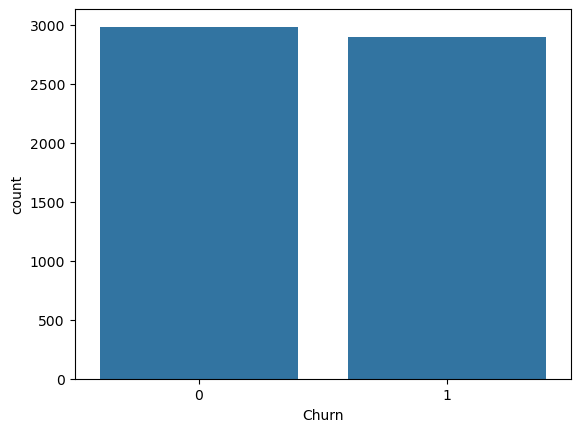

In [77]:
sns.countplot(x='Churn', data=df)

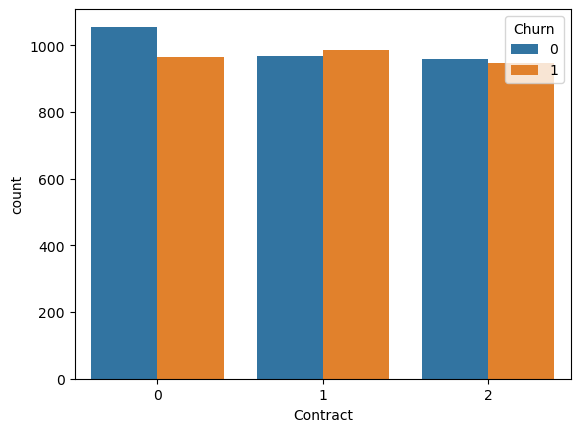

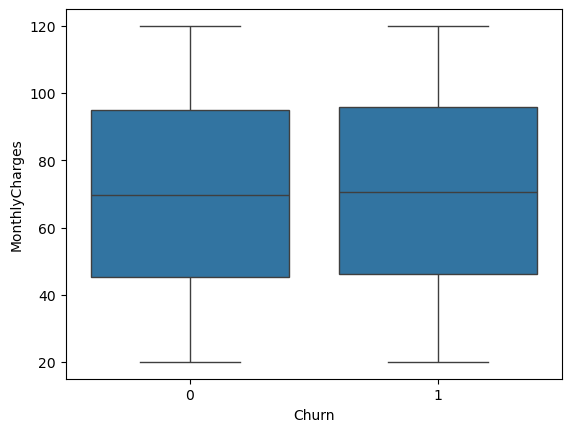

In [78]:
sns.countplot(x='Contract', hue='Churn', data=df)
plt.show()

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)
plt.show()

In [64]:
le = LabelEncoder()

for col in df.select_dtypes(include= 'object').columns:
    df[col] = le.fit_transform(df[col])

In [65]:
X = df.drop('Churn', axis=1)
y = df['Churn']

In [66]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
    
)
    


In [67]:
model = LogisticRegression()
model.fit(X_train , y_train)

C:\Users\m.rooney\AppData\Local\anaconda3\Lib\site-packages\sklearn\linear_model\_logistic.py:473: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,None
,solver,'lbfgs'
,max_iter,100
,multi_class,'deprecated'


In [73]:
y_pred = model.predict(X_test)

In [74]:
print("Accuraccy:" , accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))

Accuraccy: 0.4770408163265306
[[355 229]
 [386 206]]
              precision    recall  f1-score   support

           0       0.48      0.61      0.54       584
           1       0.47      0.35      0.40       592

    accuracy                           0.48      1176
   macro avg       0.48      0.48      0.47      1176
weighted avg       0.48      0.48      0.47      1176



In [71]:
joblib.dump(model, 'churn_model.pkl')

['churn_model.pkl']